In [ ]:
#Crime and Incarceration Classification Project

In [ ]:
# Research question

**Can prior-year state-level crime and incarceration characteristics be 
used to classify whether violent crime will decrease, remain stable, or increase in the following year?**

#Problem statement

This project examines whether patterns observed in a state's crime and 
incarceration data in one year can help classify the direction of violent 
crime in the following year. The outcome is a three-category violent-crime 
trend: **Decrease, Stable, or Increase**.

#Hypotheses
**H0:** Prior-year state-level crime and incarceration characteristics do 
not meaningfully distinguish among next-year violent-crime trend categories.

**H1:** At least one prior-year crime or incarceration characteristic helps
distinguish among next-year violent-crime trend categories.

#Working operational definition:  
A change between **-2% and +2%** is classified as Stable. This threshold 
is a project choice and can be tested later with a sensitivity analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
crime_incarceration = pd.read_csv("crime_and_incarceration_by_state.csv")
prison_custody = pd.read_csv("prison_custody_by_state.csv")
ucr = pd.read_csv("ucr_by_state.csv")

In [5]:
print("Crime and Incarceration Dataset:")
print(crime_incarceration.shape)
display(crime_incarceration.head())

print("\nPrison Custody Dataset:")
print(prison_custody.shape)
display(prison_custody.head())

print("\nUCR Dataset:")
print(ucr.shape)
display(ucr.head())

Crime and Incarceration Dataset:
(816, 17)


,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
0,FEDERAL,False,2001,149852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ALABAMA,False,2001,24741,False,False,4468912.0,19582.0,379.0,1369.0,NaN,5584.0,12250.0,173253.0,40642.0,119992.0,12619.0
2,ALASKA,True,2001,4570,False,False,633630.0,3735.0,39.0,501.0,NaN,514.0,2681.0,23160.0,3847.0,16695.0,2618.0
3,ARIZONA,False,2001,27710,False,False,5306966.0,28675.0,400.0,1518.0,NaN,8868.0,17889.0,293874.0,54821.0,186850.0,52203.0
4,ARKANSAS,False,2001,11489,False,False,2694698.0,12190.0,148.0,892.0,NaN,2181.0,8969.0,99106.0,22196.0,69590.0,7320.0



Prison Custody Dataset:
(51, 18)


,jurisdiction,includes_jails,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Federal,0,"149,852","158,216","168,144","177,600","186,364","190,844","197,285","198,414","205,087","206,968","214,774","216,915","214,989","209,561","195,622","188,311"
1,Alabama,0,"24,741","25,100","27,614","25,635","24,315","24,103","25,253","25,363","27,241","27,345","26,813","26,768","26,825","26,145","25,212","23,745"
2,Alaska,1,"4,570","4,351","4,472","4,534","4,798","5,052","5,151","4,997","5,472","5,369","6,216","6,308","5,081","6,323","5,247","4,378"
3,Arizona,0,"27,710","29,359","31,084","32,384","33,345","35,752","37,700","39,455","40,544","40,130","39,949","40,013","41,031","42,136","42,204","42,248"
4,Arkansas,0,"11,489","11,849","12,068","12,577","12,455","12,854","13,275","13,135","13,338","14,192","14,090","14,043","14,295","15,250","15,784","15,833"



UCR Dataset:
(948, 21)


,jurisdiction,year,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,...,property_crime_total,burglary,larceny,vehicle_theft,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,Alaska,2001.0,0.0,0.0,"633,630","3,735",39,501,NaN,514,...,"23,160","3,847","16,695","2,618",NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,2002.0,0.0,0.0,"641,482","3,627",33,511,NaN,489,...,"24,118","3,908","17,739","2,471",NaN,NaN,NaN,NaN,NaN,NaN
2,Alaska,2003.0,0.0,0.0,"648,280","3,877",39,605,NaN,446,...,"24,386","3,874","18,051","2,461",NaN,NaN,NaN,NaN,NaN,NaN
3,Alaska,2004.0,0.0,0.0,"657,755","4,159",37,558,NaN,447,...,"22,172","3,773","16,159","2,240",NaN,NaN,NaN,NaN,NaN,NaN
4,Alaska,2005.0,0.0,0.0,"663,253","4,194",32,538,NaN,537,...,"23,975","4,131","17,249","2,595",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Viewed Variable Names

In [6]:
print(crime_incarceration.columns.tolist())

['jurisdiction', 'includes_jails', 'year', 'prisoner_count', 'crime_reporting_change', 'crimes_estimated', 'state_population', 'violent_crime_total', 'murder_manslaughter', 'rape_legacy', 'rape_revised', 'robbery', 'agg_assault', 'property_crime_total', 'burglary', 'larceny', 'vehicle_theft']


In [7]:
#Data set Info and checking for missing values

crime_incarceration.info()

crime_incarceration.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   jurisdiction            816 non-null    object 
 1   includes_jails          816 non-null    bool   
 2   year                    816 non-null    int64  
 3   prisoner_count          816 non-null    int64  
 4   crime_reporting_change  799 non-null    object 
 5   crimes_estimated        799 non-null    object 
 6   state_population        799 non-null    float64
 7   violent_crime_total     799 non-null    float64
 8   murder_manslaughter     799 non-null    float64
 9   rape_legacy             749 non-null    float64
 10  rape_revised            199 non-null    float64
 11  robbery                 799 non-null    float64
 12  agg_assault             799 non-null    float64
 13  property_crime_total    799 non-null    float64
 14  burglary                799 non-null    fl

jurisdiction                0
includes_jails              0
year                        0
prisoner_count              0
crime_reporting_change     17
crimes_estimated           17
state_population           17
violent_crime_total        17
murder_manslaughter        17
rape_legacy                67
rape_revised              617
robbery                    17
agg_assault                17
property_crime_total       17
burglary                   17
larceny                    17
vehicle_theft              17
dtype: int64

In [8]:
#Missing values are being shown: My study is examining differences across states, so I'm removing the 
#Federal category

df = crime_incarceration[
    crime_incarceration["jurisdiction"] != "FEDERAL"
].copy()

In [11]:
#Ran missing value check again

df.isnull().sum()

jurisdiction                0
includes_jails              0
year                        0
prisoner_count              0
crime_reporting_change      1
crimes_estimated            1
state_population            1
violent_crime_total         1
murder_manslaughter         1
rape_legacy                51
rape_revised              601
robbery                     1
agg_assault                 1
property_crime_total        1
burglary                    1
larceny                     1
vehicle_theft               1
dtype: int64

In [13]:
#Confirming which observation it is

df[
    df["state_population"].isnull()
][
    [
        "jurisdiction",
        "year",
        "state_population",
        "violent_crime_total",
        "murder_manslaughter",
        "robbery",
        "agg_assault"
    ]
]

,jurisdiction,year,state_population,violent_crime_total,murder_manslaughter,robbery,agg_assault
746,NEW YORK,2015,NaN,NaN,NaN,NaN,NaN


In [14]:
#Sorting observations by state amd year

df = df.sort_values(
    ["jurisdiction", "year"]
).reset_index(drop=True)

display(df.head())

,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft
0,ALABAMA,False,2001,24741,False,False,4468912.0,19582.0,379.0,1369.0,NaN,5584.0,12250.0,173253.0,40642.0,119992.0,12619.0
1,ALABAMA,False,2002,25100,False,False,4478896.0,19931.0,303.0,1664.0,NaN,5962.0,12002.0,180400.0,42578.0,123932.0,13890.0
2,ALABAMA,False,2003,27614,False,False,4503726.0,19331.0,299.0,1656.0,NaN,6038.0,11338.0,182241.0,43245.0,124039.0,14957.0
3,ALABAMA,False,2004,25635,False,False,4525375.0,19324.0,254.0,1742.0,NaN,6042.0,11286.0,182340.0,44666.0,123650.0,14024.0
4,ALABAMA,False,2005,24315,False,False,4548327.0,19678.0,374.0,1564.0,NaN,6447.0,11293.0,177393.0,43473.0,120780.0,13140.0


In [15]:
#Creating crime rates per 100,000 people instead of raw counts because 
#states have a very different population size

df["incarceration_rate"] = (
    df["prisoner_count"] /
    df["state_population"]
) * 100000

In [20]:
#Created overall violent crime rate

df["violent_crime_rate"] = (
    df["violent_crime_total"] /
    df["state_population"]
) * 100000

In [21]:
#Created rates for individual violent crimes

df["murder_rate"] = (
    df["murder_manslaughter"] /
    df["state_population"]
) * 100000

df["rape_rate"] = (
    df["rape_legacy"] /
    df["state_population"]
) * 100000

df["robbery_rate"] = (
    df["robbery"] /
    df["state_population"]
) * 100000

df["aggravated_assault_rate"] = (
    df["agg_assault"] /
    df["state_population"]
) * 100000

In [22]:
#Additional: Created property crime rates because prior year property crime
#may help classify what happens to violent crime later.

df["property_crime_rate"] = (
    df["property_crime_total"] /
    df["state_population"]
) * 100000

df["burglary_rate"] = (
    df["burglary"] /
    df["state_population"]
) * 100000

df["larceny_rate"] = (
    df["larceny"] /
    df["state_population"]
) * 100000

df["vehicle_theft_rate"] = (
    df["vehicle_theft"] /
    df["state_population"]
) * 100000

In [23]:
#Newly created rates

rate_variables = [
    "jurisdiction",
    "year",
    "incarceration_rate",
    "violent_crime_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "property_crime_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

display(df[rate_variables].head(10))

,jurisdiction,year,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate
0,ALABAMA,2001,553.624685,438.182717,8.480811,30.633855,124.952114,274.115937,3876.849667,909.438360,2685.038327,282.372980
1,ALABAMA,2002,560.405957,444.998053,6.765060,37.152012,133.113160,267.967821,4027.778274,950.636050,2767.021159,310.121066
2,ALABAMA,2003,613.136767,429.222382,6.638947,36.769555,134.066770,251.747109,4046.449540,960.204950,2754.141793,332.102797
3,ALABAMA,2004,566.472392,427.014336,5.612795,38.494047,133.513797,249.393697,4029.279341,987.012126,2732.370246,309.896970
4,ALABAMA,2005,534.592170,432.642596,8.222804,34.386270,141.744426,248.289096,3900.181319,955.801990,2655.481895,288.897434
5,ALABAMA,2006,524.088775,425.154870,8.306099,35.790156,153.554119,227.504496,3941.026695,973.683581,2640.795994,326.547120
6,ALABAMA,2007,545.674439,448.912465,8.902620,33.449651,159.858215,246.701979,3977.699368,980.563117,2689.477254,307.658998
7,ALABAMA,2008,544.048564,452.819666,7.529119,34.706879,157.575238,253.008430,4084.514897,1081.340226,2714.322487,288.852185
8,ALABAMA,2009,578.523875,450.102236,6.838394,31.940821,133.051359,278.271662,3780.378822,1037.312146,2507.524357,235.542319
9,ALABAMA,2010,571.425467,383.729598,5.746645,28.315286,101.642475,248.025192,3527.980205,887.783490,2414.928237,225.268478


In [24]:
#Most important: Created the following year violent crime rate

df["next_year"] = (
    df.groupby("jurisdiction")["year"]
      .shift(-1)
)

df["next_year_violent_crime_rate"] = (
    df.groupby("jurisdiction")["violent_crime_rate"]
      .shift(-1)
)

In [26]:
#Checking to make sure the next observation is actually the following year

df["consecutive_year"] = (
    df["next_year"] == df["year"] + 1
)

In [27]:
df["consecutive_year"].value_counts()

consecutive_year
True     750
False     50
Name: count, dtype: int64

In [29]:
#Calculating the percentage change in violent crimes
df["violent_crime_pct_change"] = (
    (
        df["next_year_violent_crime_rate"] -
        df["violent_crime_rate"]
    )
    /
    df["violent_crime_rate"]
) * 100



#Viewing a few observations
display(
    df[
        [
            "jurisdiction",
            "year",
            "violent_crime_rate",
            "next_year",
            "next_year_violent_crime_rate",
            "violent_crime_pct_change"
        ]
    ].head(20)
)

,jurisdiction,year,violent_crime_rate,next_year,next_year_violent_crime_rate,violent_crime_pct_change
0,ALABAMA,2001,438.182717,2002.0,444.998053,1.555364
1,ALABAMA,2002,444.998053,2003.0,429.222382,-3.545110
2,ALABAMA,2003,429.222382,2004.0,427.014336,-0.514429
3,ALABAMA,2004,427.014336,2005.0,432.642596,1.318049
4,ALABAMA,2005,432.642596,2006.0,425.154870,-1.730696
5,ALABAMA,2006,425.154870,2007.0,448.912465,5.587986
6,ALABAMA,2007,448.912465,2008.0,452.819666,0.870370
7,ALABAMA,2008,452.819666,2009.0,450.102236,-0.600113
8,ALABAMA,2009,450.102236,2010.0,383.729598,-14.746125
9,ALABAMA,2010,383.729598,2011.0,419.802364,9.400569


In [31]:
#Classification Importance: 
#Decrease = more than a 2% decrease, 
#Stable = between -2% and +2%, 
#Increase = more than a 2% increase

def classify_violent_crime_trend(change):
    
    if pd.isna(change):
        return np.nan
    
    elif change < -2:
        return "Decrease"
    
    elif change <= 2:
        return "Stable"
    
    else:
        return "Increase"

#Applied Function
df["violent_crime_trend"] = (
    df["violent_crime_pct_change"]
      .apply(classify_violent_crime_trend)
)

In [32]:
#Viewed classification Outcome

df[
    [
        "jurisdiction",
        "year",
        "violent_crime_pct_change",
        "violent_crime_trend"
    ]
].head(20)

,jurisdiction,year,violent_crime_pct_change,violent_crime_trend
0,ALABAMA,2001,1.555364,Stable
1,ALABAMA,2002,-3.545110,Decrease
2,ALABAMA,2003,-0.514429,Stable
3,ALABAMA,2004,1.318049,Stable
4,ALABAMA,2005,-1.730696,Stable
5,ALABAMA,2006,5.587986,Increase
6,ALABAMA,2007,0.870370,Stable
7,ALABAMA,2008,-0.600113,Stable
8,ALABAMA,2009,-14.746125,Decrease
9,ALABAMA,2010,9.400569,Increase


In [35]:
#The year 2016 cannot predict 2017 because my data set ends in 2016; 
#Observations that cannot be used are being removed

analysis_df = df[
    (df["consecutive_year"] == True) &
    (df["violent_crime_trend"].notna())
].copy()


#Size Check
print("Number of usable observations:")
print(len(analysis_df))

#Three Outcome Category check
analysis_df["violent_crime_trend"].value_counts()

Number of usable observations:
748


violent_crime_trend
Decrease    301
Stable      225
Increase    222
Name: count, dtype: int64

In [36]:
#Calculated Percentages
trend_counts = analysis_df["violent_crime_trend"].value_counts()

trend_percent = (
    analysis_df["violent_crime_trend"]
    .value_counts(normalize=True) * 100
)

trend_summary = pd.DataFrame({
    "Count": trend_counts,
    "Percent": trend_percent
})

display(trend_summary)

,Count,Percent
violent_crime_trend,,
Decrease,301,40.240642
Stable,225,30.080214
Increase,222,29.679144


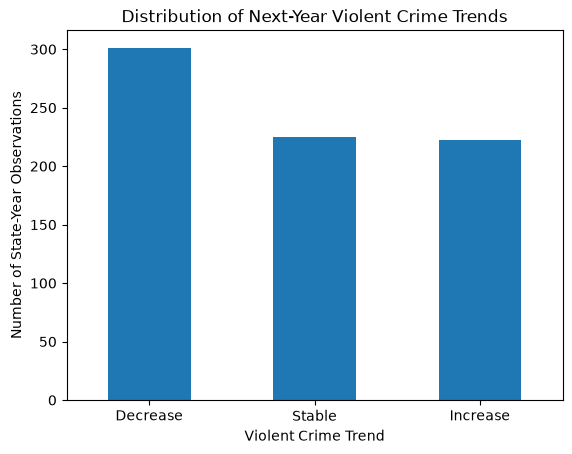

In [41]:
#Using a bar chart to show whether the three classifications are balanced

trend_order = ["Decrease", "Stable", "Increase"]

analysis_df["violent_crime_trend"].value_counts()[
    trend_order
].plot(
    kind="bar"
)

plt.title("Distribution of Next-Year Violent Crime Trends")
plt.xlabel("Violent Crime Trend")
plt.ylabel("Number of State-Year Observations")
plt.xticks(rotation=0)
plt.show()

In [45]:
#Defining my predictor variables that will be used to classify the 
#following years violent crime trend

predictor_variables = [
    "incarceration_rate",
    "violent_crime_rate",
    "murder_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate",
    "property_crime_rate",
    "burglary_rate",
    "larceny_rate",
    "vehicle_theft_rate"
]

outcome_variable = "violent_crime_trend"


#Created Final Analysis Data set
model_df = analysis_df[
    [
        "jurisdiction",
        "year"
    ] +
    predictor_variables +
    [
        "next_year",
        "next_year_violent_crime_rate",
        "violent_crime_pct_change",
        outcome_variable
    ]
].copy()


#Checking It and for missing values
display(model_df.head())


model_df.isnull().sum()

,jurisdiction,year,incarceration_rate,violent_crime_rate,murder_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,vehicle_theft_rate,next_year,next_year_violent_crime_rate,violent_crime_pct_change,violent_crime_trend
0,ALABAMA,2001,553.624685,438.182717,8.480811,30.633855,124.952114,274.115937,3876.849667,909.438360,2685.038327,282.372980,2002.0,444.998053,1.555364,Stable
1,ALABAMA,2002,560.405957,444.998053,6.765060,37.152012,133.113160,267.967821,4027.778274,950.636050,2767.021159,310.121066,2003.0,429.222382,-3.545110,Decrease
2,ALABAMA,2003,613.136767,429.222382,6.638947,36.769555,134.066770,251.747109,4046.449540,960.204950,2754.141793,332.102797,2004.0,427.014336,-0.514429,Stable
3,ALABAMA,2004,566.472392,427.014336,5.612795,38.494047,133.513797,249.393697,4029.279341,987.012126,2732.370246,309.896970,2005.0,432.642596,1.318049,Stable
4,ALABAMA,2005,534.592170,432.642596,8.222804,34.386270,141.744426,248.289096,3900.181319,955.801990,2655.481895,288.897434,2006.0,425.154870,-1.730696,Stable


jurisdiction                    0
year                            0
incarceration_rate              0
violent_crime_rate              0
murder_rate                     0
rape_rate                       0
robbery_rate                    0
aggravated_assault_rate         0
property_crime_rate             0
burglary_rate                   0
larceny_rate                    0
vehicle_theft_rate              0
next_year                       0
next_year_violent_crime_rate    0
violent_crime_pct_change        0
violent_crime_trend             0
dtype: int64

In [47]:
#Removing observations missing predictor information

model_df = model_df.dropna(
    subset=predictor_variables + [outcome_variable]
).copy()



#Checking Final sample
print("Final modeling sample:")
print(model_df.shape)

print("\nOutcome distribution:")
print(model_df["violent_crime_trend"].value_counts())

Final modeling sample:
(748, 16)

Outcome distribution:
violent_crime_trend
Decrease    301
Stable      225
Increase    222
Name: count, dtype: int64


In [48]:
#Saved New Prepared data set for Project
model_df.to_csv(
    "violent_crime_classification_ready.csv",
    index=False
)